In [ ]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, precision_recall_curve, recall_score, precision_score

from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from catboost import CatBoostClassifier

import re
import joblib
from sklearn.inspection import permutation_importance

from sklearn.model_selection import StratifiedShuffleSplit



In [ ]:
df = pd.read_csv('data.csv', parse_dates=['datetime'])
df = df.sort_values('datetime')

In [ ]:
df

,ID1,datetime,precip_helman_mm,wind_direction_deg,wind_speed_ms,temperature_c,humidity_percent,pressure_hpa,precip_vaisala_mm,solar_radiation_wm2
0,1,2012-09-19 11:35:47,0.0,235.0,2.5,16.5,65.4,985.2,1.30,297.310000
1,2,2012-09-19 12:45:01,0.0,251.0,3.5,17.3,55.6,985.3,1.30,318.977000
2,3,2012-09-19 13:00:00,0.0,229.0,3.3,17.1,58.4,985.3,1.30,286.119000
8,9,2012-09-19 13:00:58,0.0,264.0,3.7,16.8,50.4,987.3,1.30,104.502000
3,4,2012-09-19 14:00:00,0.0,223.0,1.5,18.0,53.2,985.4,1.30,441.087000
...,...,...,...,...,...,...,...,...,...,...
32196,32228,2016-10-21 03:10:01,1.7,216.0,1.8,-2.7,87.5,1006.2,77.61,-1.988290
32197,32229,2016-10-21 04:10:01,1.7,224.0,1.7,-3.5,86.5,1006.3,77.61,-3.481760
32198,32230,2016-10-21 05:10:01,1.7,195.0,0.9,-5.7,87.8,1006.6,77.61,-4.051670
32199,32231,2016-10-21 06:10:01,1.7,273.0,1.5,-4.4,89.9,1007.0,77.61,0.203466


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32201 entries, 0 to 32200
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID1                  32201 non-null  int64         
 1   datetime             32201 non-null  datetime64[ns]
 2   precip_helman_mm     32201 non-null  float64       
 3   wind_direction_deg   32201 non-null  float64       
 4   wind_speed_ms        32201 non-null  float64       
 5   temperature_c        32201 non-null  float64       
 6   humidity_percent     32201 non-null  float64       
 7   pressure_hpa         32201 non-null  float64       
 8   precip_vaisala_mm    32201 non-null  float64       
 9   solar_radiation_wm2  32201 non-null  float64       
dtypes: datetime64[ns](1), float64(8), int64(1)
memory usage: 2.7 MB


In [ ]:
print(f"Загружено записей: {len(df)}")
print(f"Период: с {df['datetime'].min()} по {df['datetime'].max()}")

Загружено записей: 32201
Период: с 2012-09-19 11:35:47 по 2016-10-21 07:10:00


In [ ]:
df.describe()

,ID1,datetime,precip_helman_mm,wind_direction_deg,wind_speed_ms,temperature_c,humidity_percent,pressure_hpa,precip_vaisala_mm,solar_radiation_wm2
count,32201.000000,32201,32201.000000,32201.00000,32201.000000,32201.000000,32201.000000,32201.000000,32201.000000,32201.000000
mean,16125.848110,2014-12-04 01:12:25.522903040,6.344983,181.64498,2.899845,6.835890,62.978476,999.312996,46.115732,162.358482
min,1.000000,2012-09-19 11:35:47,0.000000,0.00000,0.000000,-38.700000,8.500000,970.700000,0.000000,-27.344000
25%,8081.000000,2014-01-01 15:10:00,0.000000,126.00000,1.400000,-2.200000,47.900000,991.600000,18.880000,-1.863370
50%,16132.000000,2014-12-01 05:10:00,0.000000,196.00000,2.600000,8.200000,67.900000,998.600000,45.980000,10.547000
75%,24182.000000,2015-10-28 05:10:00,4.600000,239.00000,4.000000,17.800000,79.100000,1006.200000,70.600000,246.784000
max,32232.000000,2016-10-21 07:10:00,63.000000,359.00000,17.900000,37.400000,96.000000,1033.200000,99.840000,1154.780000
std,9304.179694,NaN,13.037271,88.78257,1.872665,13.867784,19.727085,10.230933,29.518249,250.930609


In [ ]:
print(f"Статистика осадков:")
print(f"Среднее: {df['precip_vaisala_mm'].mean():.2f} мм")
print(f"Медиана: {df['precip_vaisala_mm'].median():.2f} мм")
print(f"Стандартное отклонение: {df['precip_vaisala_mm'].std():.2f} мм")
print(f"Максимум: {df['precip_vaisala_mm'].max():.2f} мм")
print(f"Доля нулей: {(df['precip_vaisala_mm'] == 0).mean():.2%}")

Статистика осадков:
Среднее: 46.12 мм
Медиана: 45.98 мм
Стандартное отклонение: 29.52 мм
Максимум: 99.84 мм
Доля нулей: 0.90%


In [ ]:
print(f"Статистика осадков:")
print(f"Среднее: {df['precip_helman_mm'].mean():.2f} мм")
print(f"Медиана: {df['precip_helman_mm'].median():.2f} мм")
print(f"Стандартное отклонение: {df['precip_helman_mm'].std():.2f} мм")
print(f"Максимум: {df['precip_helman_mm'].max():.2f} мм")
print(f"Доля нулей: {(df['precip_helman_mm'] == 0).mean():.2%}")

Статистика осадков:
Среднее: 6.34 мм
Медиана: 0.00 мм
Стандартное отклонение: 13.04 мм
Максимум: 63.00 мм
Доля нулей: 51.91%


In [ ]:
df['precip_helman_mm'].value_counts()

,count
precip_helman_mm,
0.0,16715
0.2,1432
0.1,1386
37.6,440
0.3,406
...,...
14.9,1
24.0,1
27.2,1


In [ ]:
df.dtypes

,0
ID1,int64
datetime,datetime64[ns]
precip_helman_mm,float64
wind_direction_deg,float64
wind_speed_ms,float64
temperature_c,float64
humidity_percent,float64
pressure_hpa,float64
precip_vaisala_mm,float64
solar_radiation_wm2,float64


In [ ]:
Missing_Value = df.isnull().sum().sort_values(ascending = False)
Missing_Percent = (df.isnull().sum()/df.isnull().count()*100).sort_values(ascending = False)
Missing_Data = pd.concat([Missing_Value, Missing_Percent], axis=1, keys=['Пропущенные значения', 'Процент'])
Missing_Data.reset_index()

,index,Пропущенные значения,Процент
0,ID1,0,0.0
1,datetime,0,0.0
2,precip_helman_mm,0,0.0
3,wind_direction_deg,0,0.0
4,wind_speed_ms,0,0.0
5,temperature_c,0,0.0
6,humidity_percent,0,0.0
7,pressure_hpa,0,0.0
8,precip_vaisala_mm,0,0.0
9,solar_radiation_wm2,0,0.0


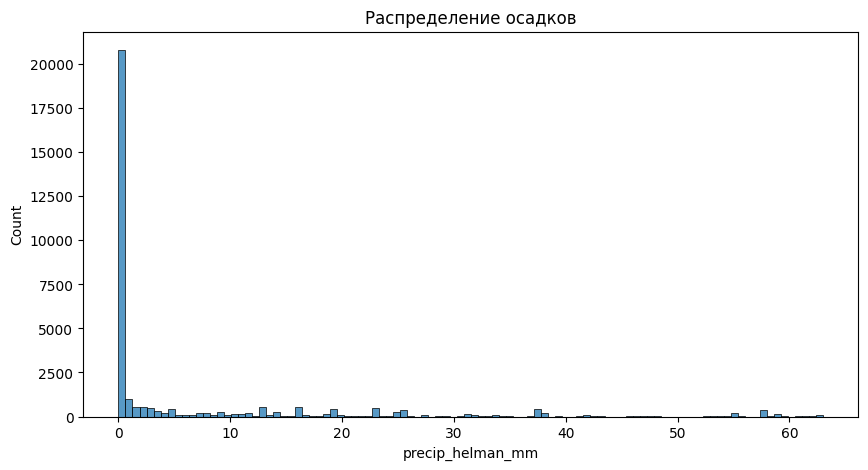

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df['precip_helman_mm'], bins=100)
plt.title('Распределение осадков')
plt.show()

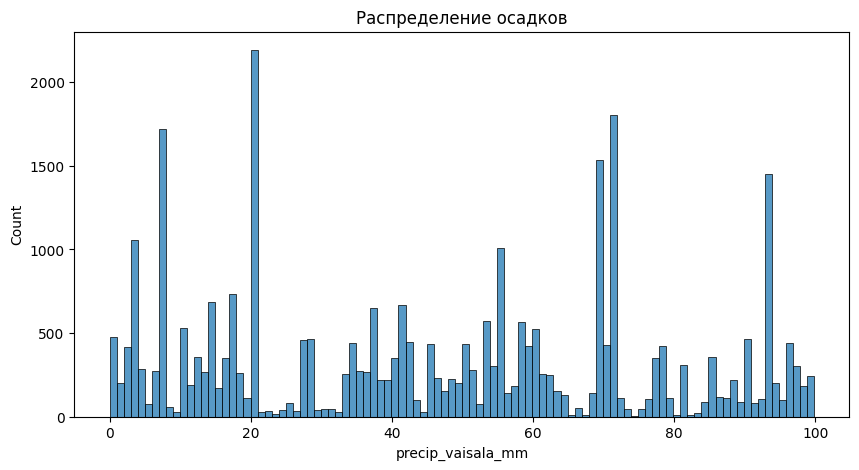

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df['precip_vaisala_mm'], bins=100)
plt.title('Распределение осадков')
plt.show()

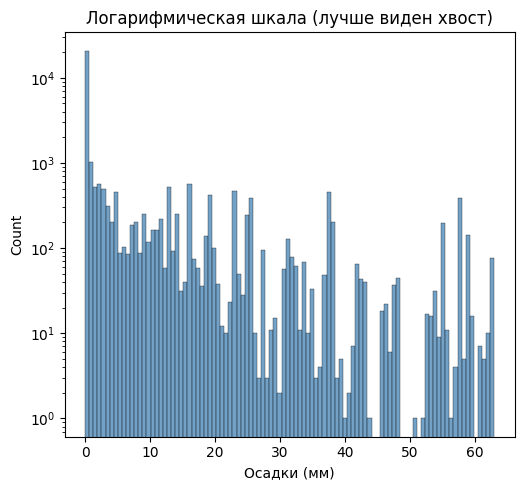

In [ ]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,2)
sns.histplot(df['precip_helman_mm'], bins=100, color='steelblue', edgecolor='black')
plt.yscale('log')  # логарифмическая шкала Y
plt.title('Логарифмическая шкала (лучше виден хвост)')
plt.xlabel('Осадки (мм)')
plt.tight_layout()
plt.show()

In [ ]:
df['future_rain_mm'] = (df['precip_helman_mm'].shift(-24))
df['target_rain_24h'] = (df['future_rain_mm'] > 0).astype(int)
df[['future_rain_mm','target_rain_24h']].head()

,future_rain_mm,target_rain_24h
0,0.0,0
1,0.0,0
2,0.0,0
8,0.0,0
3,0.0,0


In [ ]:
target_distribution = (df['target_rain_24h'].value_counts(normalize=True))
print(target_distribution)

target_rain_24h
0    0.519083
1    0.480917
Name: proportion, dtype: float64


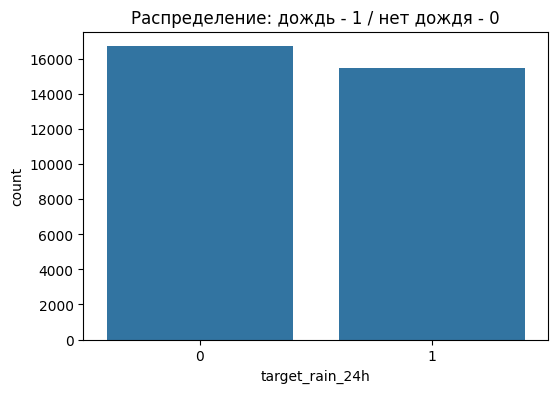

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x=df['target_rain_24h'])
plt.title('Распределение: дождь - 1 / нет дождя - 0')
plt.show()

In [ ]:
df = df.sort_values('datetime')
df = (df.set_index('datetime').resample('1H').mean())
#Было: 12:30, 13:15, 14:45
#Стало: 12:00, 13:00, 14:00

/tmp/ipykernel_3766/1667883943.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df = (df.set_index('datetime').resample('1H').mean())


In [ ]:
df = df.interpolate()
# это если в 11 например 10градусов, в 12 nan, 13 14градусов, то в 12 будет 12градусов

In [ ]:
df = df.reset_index()

In [ ]:
def create_features(df):
    df = df.copy()

    # базовые временные признаки
    df['hour'] = df['datetime'].dt.hour
    df['dayofweek'] = df['datetime'].dt.dayofweek
    df['month'] = df['datetime'].dt.month
    df['dayofyear'] = df['datetime'].dt.dayofyear

    # циклическое кодирование
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    df['dayofweek_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
    df['dayofweek_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)
    df['dayofyear_sin'] = np.sin(2 * np.pi * df['dayofyear'] / 365)
    df['dayofyear_cos'] = np.cos(2 * np.pi * df['dayofyear'] / 365)

    #
    df['season'] = df['month'].apply(lambda m:
        0 if m in [12, 1, 2] else   # зима
        1 if m in [3, 4, 5] else    # весна
        2 if m in [6, 7, 8] else 3) # лето, осень

    df['season_sin'] = np.sin(2 * np.pi * df['season'] / 4)
    df['season_cos'] = np.cos(2 * np.pi * df['season'] / 4)

    # флаги сезонов
    df['is_winter'] = (df['season'] == 0).astype(int)
    df['is_spring'] = (df['season'] == 1).astype(int)
    df['is_summer'] = (df['season'] == 2).astype(int)
    df['is_autumn'] = (df['season'] == 3).astype(int)

    # у направление ветра в градусах(360 и 0 фактически одно и то же, а вот 180 и 0 это противополжные направления)
    df['wind_dir_sin'] = np.sin(np.deg2rad(df['wind_direction_deg']))
    df['wind_dir_cos'] = np.cos(np.deg2rad(df['wind_direction_deg']))

    # лаги осадков
    lags = [1, 2, 3, 6, 12, 24, 36, 48, 72, 96, 120, 168]
    for lag in lags:
        df[f'precip_lag_{lag}h'] = df['precip_helman_mm'].shift(lag)

    # сдвиг осадков на час, чтобы не использовать текущий час в скользящих окнах
    shifted_rain = df['precip_helman_mm'].shift(1)

    # окна для просмотра истории последних часов и вычисления статистики в этот промежуток
    windows = [1, 2, 3, 6, 12, 24, 36, 48, 72, 96, 120, 168]
    for window in windows:
        df[f'precip_mean_{window}h'] = shifted_rain.rolling(window).mean()
        df[f'precip_max_{window}h'] = shifted_rain.rolling(window).max()
        df[f'precip_sum_{window}h'] = shifted_rain.rolling(window).sum()

    # средняя интенсивность за периоды
    for window in [6, 12, 24, 48, 72, 168]:
        df[f'precip_intensity_{window}h'] = df[f'precip_sum_{window}h'] / window

    # максимальная часовая интенсивность в окне
    for window in [24, 72, 168]:
        df[f'precip_max_intensity_{window}h'] = shifted_rain.rolling(window).max()

    # накопленные осадки
    df['precip_sum_30d'] = shifted_rain.rolling(720).sum()
    df['precip_sum_7d'] = shifted_rain.rolling(168).sum()
    df['precip_sum_24h'] = shifted_rain.rolling(24).sum()

    # был ли дождь за последние часы
    for window in [6, 12, 24, 48, 72, 168]:
        df[f'rain_hours_{window}h'] = (shifted_rain > 0).rolling(window).sum()

    # тренды за n часов (скорость изменения давления, температуры, влажности)
    trend_windows = [1, 2, 3, 6, 12, 24, 48]
    for w in trend_windows:
        df[f'pressure_trend_{w}h'] = df['pressure_hpa'].diff(w)
        df[f'pressure_acceleration_{w}h'] = df['pressure_hpa'].diff(w).diff(w)
        df[f'temp_trend_{w}h'] = df['temperature_c'].diff(w)
        df[f'temp_acceleration_{w}h'] = df['temperature_c'].diff(w).diff(w)
        df[f'humidity_trend_{w}h'] = df['humidity_percent'].diff(w)

        if w <= 6:
            df[f'wind_trend_{w}h'] = df['wind_speed_ms'].diff(w)
            if 'wind_gust_ms' in df.columns:
                df[f'wind_gust_trend_{w}h'] = df['wind_gust_ms'].diff(w)

    # флаг пасмурно/ночь - 1 если радиация меньше 50 Вт/м² (темно), 0 - норм освещенность
    df['solar_radiation_wm2'] = df['solar_radiation_wm2'].clip(lower=0)
    df['low_solar_flag'] = (df['solar_radiation_wm2'] < 50).astype(int)
    df['very_low_solar_flag'] = (df['solar_radiation_wm2'] < 10).astype(int)

    # сама целевая, (сдвиг из будущ в настоящ t+24) и создание бинарной целевой(1-да,0-нет)
    df['future_rain_mm'] = df['precip_helman_mm'].shift(-24)
    df['target_rain_24h'] = (df['future_rain_mm'] > 0).astype(int)





    return df

In [ ]:
# время суток (утро/день/вечер/ночь)
    df['time_of_day'] = pd.cut(df['hour'],
                                bins=[0, 6, 12, 18, 24],
                                labels=[0, 1, 2, 3],
                                include_lowest=True)

    # выходной или будний день
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)

    # сухой период (сколько часов не было дождя)
    df['dry_hours'] = df.groupby((shifted_rain > 0).cumsum()).cumcount()
    df['dry_hours'] = df['dry_hours'].where(shifted_rain == 0, 0)

    # недавний дождь (был ли дождь в последние n часов)
    for window in [3, 6, 12]:
        df[f'recent_rain_{window}h'] = (shifted_rain.rolling(window).sum() > 0).astype(int)

In [ ]:
df = df.sort_values('datetime')

In [ ]:
df_features = create_features(df)
df_features = df_features.dropna()

/tmp/ipykernel_3766/529782726.py:74: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'pressure_trend_{w}h'] = df['pressure_hpa'].diff(w)
/tmp/ipykernel_3766/529782726.py:75: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'pressure_acceleration_{w}h'] = df['pressure_hpa'].diff(w).diff(w)
/tmp/ipykernel_3766/529782726.py:76: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis

In [ ]:
df_features

,datetime,ID1,precip_helman_mm,wind_direction_deg,wind_speed_ms,temperature_c,humidity_percent,pressure_hpa,precip_vaisala_mm,solar_radiation_wm2,...,temp_acceleration_48h,humidity_trend_48h,low_solar_flag,very_low_solar_flag,time_of_day,is_weekend,dry_hours,recent_rain_3h,recent_rain_6h,recent_rain_12h
720,2012-10-19 11:00:00,727.0,25.8,256.0,4.6,6.4,40.9,1007.5,37.20,141.498000,...,-5.2,12.6,0,0,1,0,0,1,1,1
721,2012-10-19 12:00:00,728.0,25.8,218.0,2.5,5.2,48.4,1007.6,37.20,26.079300,...,-4.7,16.4,1,0,1,0,0,1,1,1
722,2012-10-19 13:00:00,729.0,25.8,192.0,1.4,4.1,52.6,1007.8,37.20,0.000000,...,-5.6,12.6,1,1,2,0,0,1,1,1
723,2012-10-19 14:00:00,730.0,25.8,199.0,1.4,4.0,51.6,1007.8,37.20,0.000000,...,-6.2,0.9,1,1,2,0,0,1,1,1
724,2012-10-19 15:00:00,731.0,25.8,209.0,2.2,4.4,49.9,1007.6,37.20,0.000000,...,-7.8,-1.7,1,1,2,0,0,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35800,2016-10-20 03:00:00,32203.0,1.0,189.0,2.7,-3.1,82.5,1003.4,77.61,0.000000,...,6.3,-1.0,1,1,0,0,0,1,1,1
35801,2016-10-20 04:00:00,32204.0,1.0,191.0,3.0,-3.2,85.4,1003.1,77.61,0.000000,...,6.5,2.9,1,1,0,0,0,1,1,1
35802,2016-10-20 05:00:00,32205.0,1.0,197.0,2.9,-2.4,85.0,1003.0,77.61,0.000000,...,8.8,0.9,1,1,0,0,0,1,1,1
35803,2016-10-20 06:00:00,32206.0,1.0,170.0,4.1,-1.9,85.3,1002.9,77.61,0.000000,...,9.7,2.4,1,1,0,0,0,1,1,1


In [ ]:
Missing_Value = df_features.isnull().sum().sort_values(ascending = False)
Missing_Percent = (df_features.isnull().sum()/df_features.isnull().count()*100).sort_values(ascending = False)
Missing_Data = pd.concat([Missing_Value, Missing_Percent], axis=1, keys=['Пропущенные значения', 'Процент'])
Missing_Data.reset_index()

,index,Пропущенные значения,Процент
0,datetime,0,0.0
1,ID1,0,0.0
2,precip_helman_mm,0,0.0
3,wind_direction_deg,0,0.0
4,wind_speed_ms,0,0.0
...,...,...,...
140,is_weekend,0,0.0
141,dry_hours,0,0.0
142,recent_rain_3h,0,0.0
143,recent_rain_6h,0,0.0


In [ ]:
df_features.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35085 entries, 720 to 35804
Columns: 145 entries, datetime to recent_rain_12h
dtypes: category(1), datetime64[ns](1), float64(126), int32(4), int64(13)
memory usage: 38.3 MB


In [ ]:
print(f"Создано признаков: {len(df_features.columns) - len(df.columns)}")
print(f"Всего колонок в датасете: {len(df_features.columns)}")

Создано признаков: 133
Всего колонок в датасете: 145


In [ ]:
exclude_cols = [
    'datetime',
    'target_rain_24h',
    'future_rain_mm',
    'ID1'
]
feature_cols = [col for col in df_features.columns if col not in exclude_cols]

In [ ]:
x = df_features[feature_cols]
y = df_features['target_rain_24h']

In [ ]:
x = df_features.drop('target_rain_24h', axis=1)
y = df_features['target_rain_24h']

In [ ]:
datetime_cols = x.select_dtypes(include=['datetime64']).columns
x = x.drop(columns=datetime_cols)

In [ ]:
print(f"x shape: {x.shape}")
print(f"y shape: {y.shape}")
print(f"Распределение цели: \n{y.value_counts(normalize=True)}")

x shape: (35085, 135)
y shape: (35085,)
Распределение цели: 
target_rain_24h
1    0.54405
0    0.45595
Name: proportion, dtype: float64


In [ ]:
y.value_counts(normalize=True)

,proportion
target_rain_24h,
1,0.54405
0,0.45595


In [ ]:
y.value_counts()

,count
target_rain_24h,
1,19088
0,15997


In [ ]:
"""
split_idx = int(len(x) * 0.7)

x_train = x.iloc[:split_idx]
x_test = x.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print(x_train.shape)
print(x_test.shape)

(24559, 135)
(10526, 135)


In [ ]:
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, test_idx = next(sss.split(x, df_features['season']))
x_train = x.iloc[sorted(train_idx)]
x_test = x.iloc[sorted(test_idx)]
y_train = y.iloc[sorted(train_idx)]
y_test = y.iloc[sorted(test_idx)]

In [ ]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

target_rain_24h
1    0.545625
0    0.454375
Name: proportion, dtype: float64
target_rain_24h
1    0.540376
0    0.459624
Name: proportion, dtype: float64


смещение, поэтому в модели надо добавить балансировку

In [ ]:
"""
def get_optimal_timeseries_params(x, forecast_hours=24, min_train_size=100):
    n_samples = len(x)
    test_size_ratio = 0.2
    test_size = int(n_samples * test_size_ratio)

    max_splits = 1
    for n_splits in range(5, 0, -1):
        total_needed = n_splits * (test_size + forecast_hours) + min_train_size
        if total_needed <= n_samples:
            max_splits = n_splits
            break


    recommended_splits = min(max_splits, 3)
    recommended_gap = min(forecast_hours, n_samples // 10)


    print(f"Всего записей: {n_samples}")
    print(f"Горизонт прогноза: {forecast_hours} часов")
    print(f"Минимальный размер train: {min_train_size}")
    print(f"Рекомендуемые параметры:")
    print(f"  • n_splits = {recommended_splits} (максимум {max_splits})")
    print(f"  • gap = {recommended_gap}")

    return recommended_splits, recommended_gap

n_splits_optimal, gap_optimal = get_optimal_timeseries_params(x, forecast_hours=24)

In [ ]:
tscv = TimeSeriesSplit(n_splits=5,gap=24)

In [ ]:
for i, (train_index, test_index) in enumerate(tscv.split(x)):
    print(f"Fold {i}:")
    print(f"Train: index={train_index}")
    print(f"Test:  index={test_index}")

Fold 0:
Train: index=[   0    1    2 ... 5823 5824 5825]
Test:  index=[ 5850  5851  5852 ... 11694 11695 11696]
Fold 1:
Train: index=[    0     1     2 ... 11670 11671 11672]
Test:  index=[11697 11698 11699 ... 17541 17542 17543]
Fold 2:
Train: index=[    0     1     2 ... 17517 17518 17519]
Test:  index=[17544 17545 17546 ... 23388 23389 23390]
Fold 3:
Train: index=[    0     1     2 ... 23364 23365 23366]
Test:  index=[23391 23392 23393 ... 29235 29236 29237]
Fold 4:
Train: index=[    0     1     2 ... 29211 29212 29213]
Test:  index=[29238 29239 29240 ... 35082 35083 35084]


RandomForest

In [ ]:
rf_model = RandomForestClassifier(
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

In [ ]:

params_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 8, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4, 5]
}
#{'rf__max_depth': 5, 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 5, 'rf__n_estimators': 100}

In [ ]:

params_rf = {
    'n_estimators': [100],
    'max_depth': [5],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1]
}

In [ ]:
grid_rf = GridSearchCV(
    estimator=rf_model,
    param_grid=params_rf,
    scoring='roc_auc',
    cv=tscv,
    verbose=2,
    n_jobs=-1
)
grid_rf.fit(x_train,y_train)
print(grid_rf.best_params_)

Fitting 5 folds for each of 2 candidates, totalling 10 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan]
  warnings.warn(


{'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [ ]:
best_rf = grid_rf.best_estimator_

In [ ]:
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
best_threshold = 0.5
best_f1 = 0

In [ ]:
"""
rf_probabilities = best_rf.predict_proba(x_test)[:, 1]
print("Threshold | Accuracy | Precision   | Recall    | F1-Score    | ROC-AUC")
print("—" * 80)
for threshold in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    rf_predictions = (rf_probabilities > threshold).astype(int)
    print(
        f"{threshold:.1f}       | "
        f"{accuracy_score(y_test, rf_predictions):.3f}     | "
        f"{precision_score(y_test, rf_predictions):.3f}      | "
        f"{recall_score(y_test, rf_predictions):.3f}     | "
        f"{f1_score(y_test, rf_predictions):.3f}       | "
        f"{roc_auc_score(y_test, rf_probabilities):.3f}")

Threshold | Accuracy | Precision   | Recall    | F1-Score    | ROC-AUC
————————————————————————————————————————————————————————————————————————————————
0.3       | 0.835     | 0.808      | 0.911     | 0.856       | 0.939
0.4       | 0.835     | 0.836      | 0.863     | 0.849       | 0.939
0.5       | 0.828     | 0.846      | 0.835     | 0.840       | 0.939
0.6       | 0.854     | 0.957      | 0.764     | 0.849       | 0.939
0.7       | 0.784     | 0.994      | 0.605     | 0.752       | 0.939
0.8       | 0.772     | 0.994      | 0.582     | 0.735       | 0.939
0.9       | 0.749     | 0.997      | 0.537     | 0.698       | 0.939


In [ ]:
"""
#rf_probabilities = (best_rf.predict_proba(x_test)[:,1])
threshold = 0.4
#rf_predictions = (rf_probabilities > threshold).astype(int)
rf_accuracy = accuracy_score(y_test, rf_predictions)
rf_precision = precision_score(y_test, rf_predictions)
rf_recall = recall_score(y_test, rf_predictions)
rf_f1 = f1_score(y_test, rf_predictions)
rf_roc_auc = roc_auc_score(y_test, rf_probabilities)

print(f'Accuracy: {rf_accuracy:.3f}')
print(f'Precision: {rf_precision:.3f}')
print(f'Recall: {rf_recall:.3f}')
print(f'F1: {rf_f1:.3f}')
print(f'ROC_AUC: {rf_roc_auc:.3f}')

Accuracy: 0.749
Precision: 0.997
Recall: 0.537
F1: 0.698
ROC_AUC: 0.939


In [ ]:
rf_probabilities = best_rf.predict_proba(x_test)[:, 1]
rf_roc_auc = roc_auc_score(y_test, rf_probabilities)
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
best_threshold = 0.5
best_f1 = 0

for threshold in thresholds:
    rf_predictions = (rf_probabilities > threshold).astype(int)
    current_f1 = f1_score(y_test, rf_predictions)
    if current_f1 > best_f1:
        best_f1 = current_f1
        best_threshold = threshold

rf_predictions = (rf_probabilities > best_threshold).astype(int)

rf_accuracy = accuracy_score(y_test, rf_predictions)
rf_precision = precision_score(y_test, rf_predictions)
rf_recall = recall_score(y_test, rf_predictions)
rf_f1 = f1_score(y_test, rf_predictions)

print(f'Best threshold: {best_threshold}')
print(f'Accuracy: {rf_accuracy:.3f}')
print(f'Precision: {rf_precision:.3f}')
print(f'Recall: {rf_recall:.3f}')
print(f'F1: {rf_f1:.3f}')
print(f'ROC_AUC: {rf_roc_auc:.3f}')

Best threshold: 0.3
Accuracy: 0.835
Precision: 0.808
Recall: 0.911
F1: 0.856
ROC_AUC: 0.939


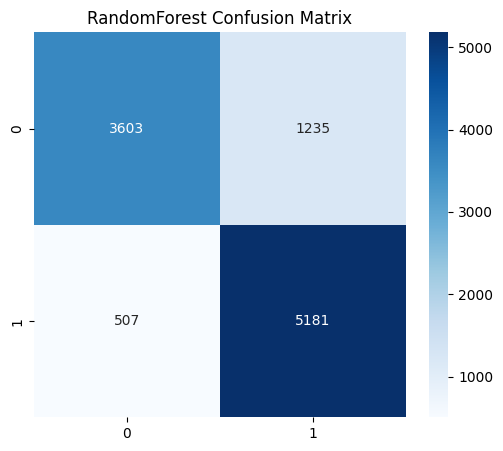

In [ ]:
cm = confusion_matrix(y_test, rf_predictions)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('RandomForest Confusion Matrix')
plt.show()

In [ ]:
importance_df_rf = pd.DataFrame({'feature': x.columns, 'importance': best_rf.feature_importances_})
importance_df_rf = (importance_df_rf.sort_values('importance', ascending=False))
importance_df_rf.head(20)

,feature,importance
42,precip_max_1h,0.098061
43,precip_sum_1h,0.069157
93,rain_hours_168h,0.051499
137,dry_hours,0.047264
29,precip_lag_1h,0.046311
41,precip_mean_1h,0.044864
48,precip_max_3h,0.044496
0,precip_helman_mm,0.041294
30,precip_lag_2h,0.038192
49,precip_sum_3h,0.037486


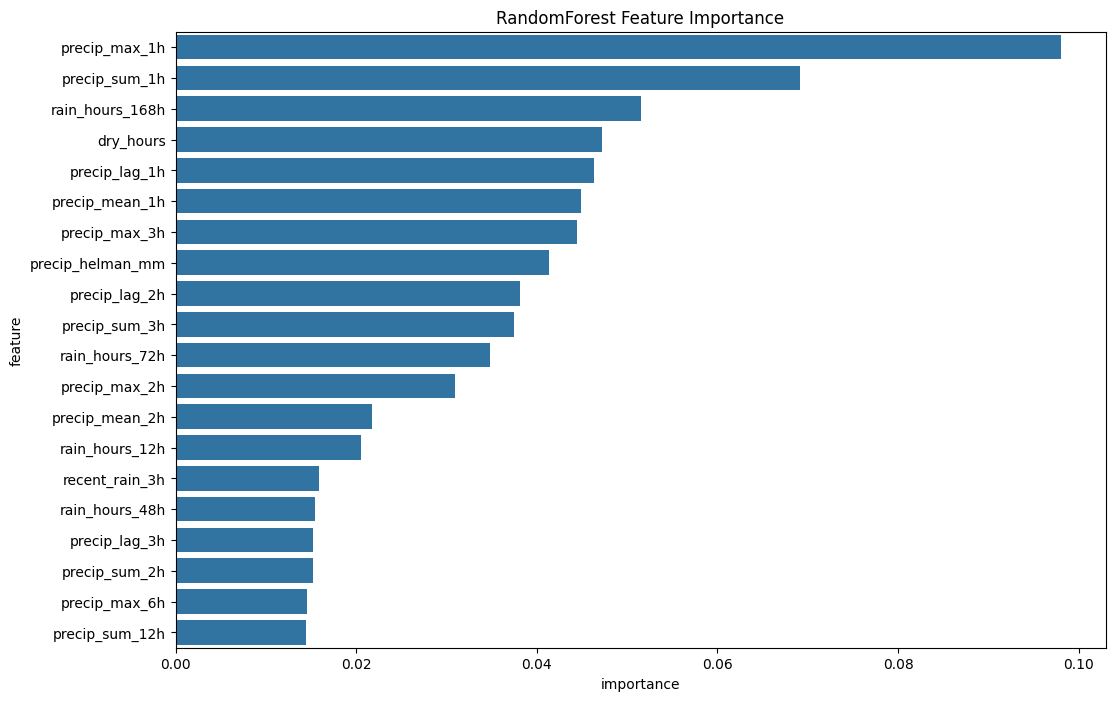

In [ ]:
plt.figure(figsize=(12,8))
sns.barplot(
    data=importance_df_rf.head(20),
    x='importance',
    y='feature'
)
plt.title('RandomForest Feature Importance')
plt.show()

LightGBM

In [ ]:
lgb_model = LGBMClassifier(
    random_state=42,
    verbose=-1,
    class_weight='balanced'
)

In [ ]:

params_lgb = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [5, 7, 9, 11],
    'num_leaves': [31, 50, 100]
}
#{'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100, 'num_leaves': 31}
#{'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 100, 'num_leaves': 31}

In [ ]:
params_lgb = {
    'n_estimators': [100],
    'learning_rate': [0.01],
    'max_depth': [5]
}

In [ ]:
grid_lgb = GridSearchCV(
    estimator=lgb_model,
    param_grid=params_lgb,
    scoring='roc_auc',
    cv=tscv,
    verbose=2,
    n_jobs=-1
)
grid_lgb.fit(x_train, y_train)
print(grid_lgb.best_params_)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
{'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 100}


In [ ]:
best_lgb = grid_lgb.best_estimator_

In [ ]:
lgb_probabilities = best_lgb.predict_proba(x_test)[:, 1]
lgb_roc_auc = roc_auc_score(y_test, lgb_probabilities)

for threshold in thresholds:
    lgb_predictions = (lgb_probabilities > threshold).astype(int)
    current_f1 = f1_score(y_test, lgb_predictions)
    if current_f1 > best_f1:
        best_f1 = current_f1
        best_threshold = threshold

lgb_predictions = (lgb_probabilities > best_threshold).astype(int)

lgb_accuracy = accuracy_score(y_test, lgb_predictions)
lgb_precision = precision_score(y_test, lgb_predictions)
lgb_recall = recall_score(y_test, lgb_predictions)
lgb_f1 = f1_score(y_test, lgb_predictions)

print(f'Best threshold: {best_threshold}')
print(f'Accuracy: {lgb_accuracy:.3f}')
print(f'Precision: {lgb_precision:.3f}')
print(f'Recall: {lgb_recall:.3f}')
print(f'F1: {lgb_f1:.3f}')
print(f'ROC_AUC: {lgb_roc_auc:.3f}')

Best threshold: 0.5
Accuracy: 0.875
Precision: 0.907
Recall: 0.857
F1: 0.881
ROC_AUC: 0.953


In [ ]:
"""
lgb_probabilities = (best_lgb.predict_proba(x_test)[:,1])
print("Threshold | Accuracy | Precision   | Recall    | F1-Score    | ROC-AUC")
print("—" * 80)
for threshold in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    lgb_predictions = (lgb_probabilities > threshold).astype(int)
    print(
        f"{threshold:.1f}       | "
        f"{accuracy_score(y_test, lgb_predictions):.3f}     | "
        f"{precision_score(y_test, lgb_predictions):.3f}      | "
        f"{recall_score(y_test, lgb_predictions):.3f}     | "
        f"{f1_score(y_test, lgb_predictions):.3f}       | "
        f"{roc_auc_score(y_test, lgb_probabilities):.3f}")

Threshold | Accuracy | Precision   | Recall    | F1-Score    | ROC-AUC
————————————————————————————————————————————————————————————————————————————————
0.3       | 0.798     | 0.739      | 0.968     | 0.838       | 0.953
0.4       | 0.852     | 0.820      | 0.928     | 0.871       | 0.953
0.5       | 0.875     | 0.907      | 0.857     | 0.881       | 0.953
0.6       | 0.833     | 0.991      | 0.697     | 0.818       | 0.953
0.7       | 0.789     | 0.998      | 0.612     | 0.758       | 0.953
0.8       | 0.764     | 1.000      | 0.563     | 0.721       | 0.953
0.9       | 0.460     | 0.000      | 0.000     | 0.000       | 0.953


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
"""
lgb_probabilities = (best_lgb.predict_proba(x_test)[:,1])
threshold = 0.5
lgb_predictions = (lgb_probabilities > threshold).astype(int)

In [ ]:
"""
lgb_accuracy = accuracy_score(y_test, lgb_predictions)
lgb_precision = precision_score(y_test, lgb_predictions)
lgb_recall = recall_score(y_test,lgb_predictions)
lgb_f1 = f1_score(y_test, lgb_predictions)
lgb_roc_auc = roc_auc_score(y_test, lgb_probabilities)

print(f'Accuracy: {lgb_accuracy:.2f}')
print(f'Precision: {lgb_precision:.2f}')
print(f'Recall: {lgb_recall:.3f}')
print(f'F1: {lgb_f1:.3f}')
print(f'ROC_AUC: {lgb_roc_auc:.2f}')

Accuracy: 0.87
Precision: 0.91
Recall: 0.857
F1: 0.881
ROC_AUC: 0.95


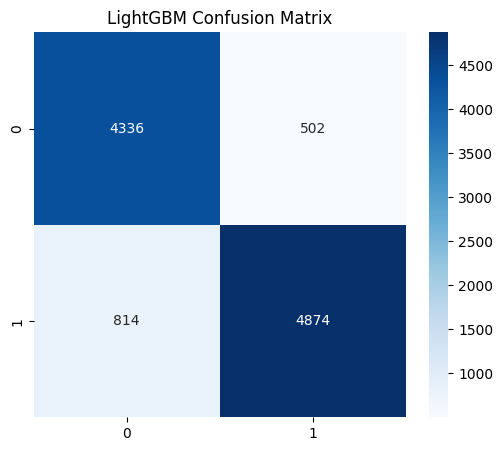

In [ ]:
cm = confusion_matrix(y_test, lgb_predictions)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('LightGBM Confusion Matrix')
plt.show()

In [ ]:
importance_df_lgb = pd.DataFrame({'feature': x.columns, 'importance': best_lgb.feature_importances_})
importance_df_lgb = (importance_df_lgb.sort_values('importance', ascending=False))
importance_df_lgb.head(20)

,feature,importance
5,pressure_hpa,427
18,dayofyear_sin,198
19,dayofyear_cos,185
6,precip_vaisala_mm,134
93,rain_hours_168h,122
86,precip_sum_30d,115
11,dayofyear,95
0,precip_helman_mm,91
38,precip_lag_96h,90
92,rain_hours_72h,85


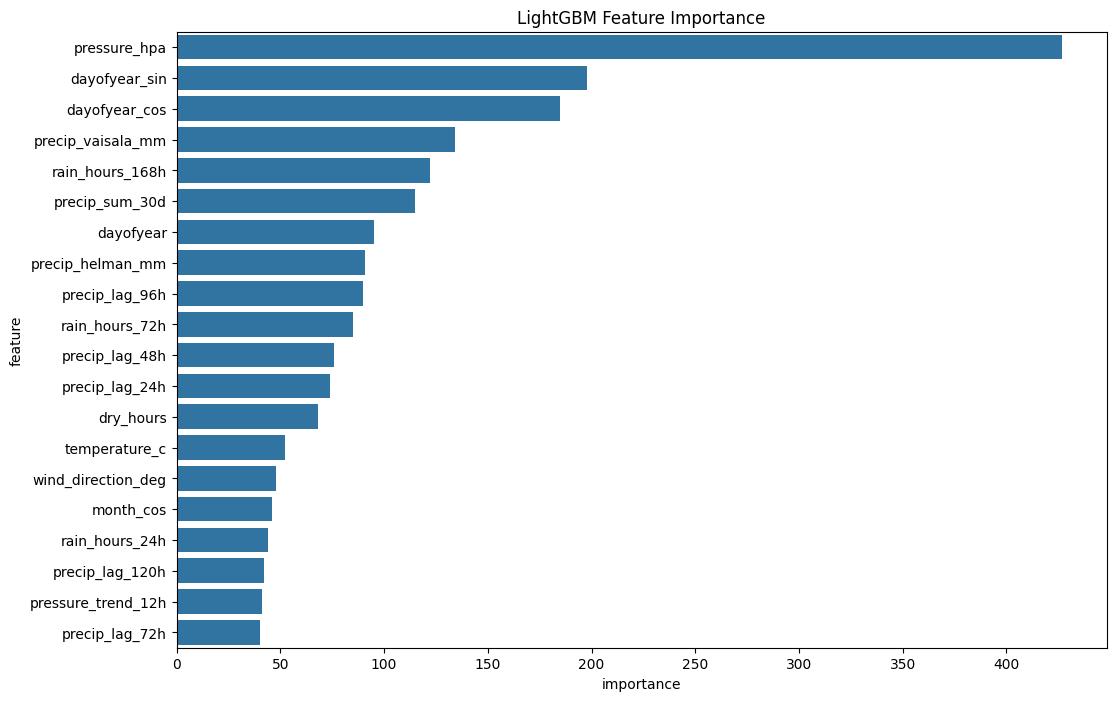

In [ ]:
plt.figure(figsize=(12,8))
sns.barplot(
    data=importance_df_lgb.head(20),
    x='importance',
    y='feature'
)
plt.title('LightGBM Feature Importance')
plt.show()

MLP

In [ ]:
mlp_model = MLPClassifier(max_iter=1000,
                          random_state=42,
                          early_stopping=True)

In [ ]:

params_mlp = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50), (100, 100)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.01, 0.1],
    'batch_size': [32, 64, 128]
}


In [ ]:
params_mlp = {
    'hidden_layer_sizes': [],
    'activation': ['relu'],
    'alpha': [0.0001],
    'learning_rate_init': [0.001],
    'batch_size': [32]
}

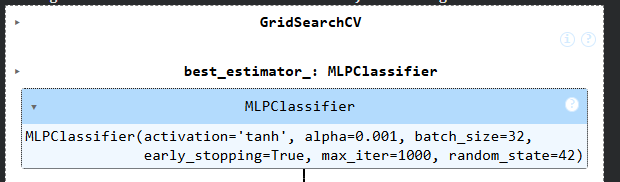

In [ ]:
grid_mlp = GridSearchCV(
    estimator=mlp_model,
    param_grid=params_mlp,
    scoring='roc_auc',
    cv=tscv,
    verbose=2,
    n_jobs=-1
)
grid_mlp.fit(x_train, y_train)

Fitting 5 folds for each of 270 candidates, totalling 1350 fits


GridSearchCV(cv=TimeSeriesSplit(gap=24, max_train_size=None, n_splits=5, test_size=None),
             estimator=MLPClassifier(early_stopping=True, max_iter=1000,
                                     random_state=42),
             n_jobs=-1,
             param_grid={'activation': ['relu', 'tanh'],
                         'alpha': [0.0001, 0.001, 0.01],
                         'batch_size': [32, 64, 128],
                         'hidden_layer_sizes': [(50,), (100,), (50, 50),
                                                (100, 50), (100, 100)],
                         'learning_rate_init': [0.001, 0.01, 0.1]},
             scoring='roc_auc', verbose=2)

In [ ]:
best_mlp = grid_mlp.best_estimator_

In [ ]:
mlp_probabilities = best_mlp.predict_proba(x_test)[:, 1]
mlp_roc_auc = roc_auc_score(y_test, mlp_probabilities)

for threshold in thresholds:
    mlp_predictions = (mlp_probabilities > threshold).astype(int)
    current_f1 = f1_score(y_test, mlp_predictions)
    if current_f1 > best_f1:
        best_f1 = current_f1
        best_threshold = threshold

mlp_predictions = (mlp_probabilities > best_threshold).astype(int)

mlp_accuracy = accuracy_score(y_test, mlp_predictions)
mlp_precision = precision_score(y_test, mlp_predictions)
mlp_recall = recall_score(y_test, mlp_predictions)
mlp_f1 = f1_score(y_test, mlp_predictions)

print(f'Best threshold: {best_threshold}')
print(f'Accuracy: {mlp_accuracy:.3f}')
print(f'Precision: {mlp_precision:.3f}')
print(f'Recall: {mlp_recall:.3f}')
print(f'F1: {mlp_f1:.3f}')
print(f'ROC_AUC: {mlp_roc_auc:.3f}')

Best threshold: 0.5
Accuracy: 0.818
Precision: 0.851
Recall: 0.805
F1: 0.827
ROC_AUC: 0.908


In [ ]:
"""
mlp_probabilities = (best_mlp.predict_proba(x_test)[:,1])
print("Threshold | Accuracy | Precision   | Recall    | F1-Score    | ROC-AUC")
print("—" * 80)
for threshold in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    mlp_predictions = (mlp_probabilities > threshold).astype(int)
    print(
        f"{threshold:.1f}       | "
        f"{accuracy_score(y_test, mlp_predictions):.3f}     | "
        f"{precision_score(y_test, mlp_predictions):.3f}      | "
        f"{recall_score(y_test, mlp_predictions):.3f}     | "
        f"{f1_score(y_test, mlp_predictions):.3f}       | "
        f"{roc_auc_score(y_test, mlp_probabilities):.3f}")

Threshold | Accuracy | Precision   | Recall    | F1-Score    | ROC-AUC
————————————————————————————————————————————————————————————————————————————————
0.3       | 0.796     | 0.765      | 0.899     | 0.827       | 0.908
0.4       | 0.808     | 0.797      | 0.866     | 0.830       | 0.908
0.5       | 0.818     | 0.851      | 0.805     | 0.827       | 0.908
0.6       | 0.813     | 0.887      | 0.749     | 0.812       | 0.908
0.7       | 0.800     | 0.921      | 0.688     | 0.788       | 0.908
0.8       | 0.767     | 0.959      | 0.594     | 0.733       | 0.908
0.9       | 0.744     | 0.985      | 0.535     | 0.694       | 0.908


In [ ]:
"""
mlp_probabilities = (best_mlp.predict_proba(x_test)[:,1])
threshold = 0.5
mlp_predictions = (mlp_probabilities > threshold).astype(int)

In [ ]:
mlp_accuracy = accuracy_score(y_test, mlp_predictions)
mlp_precision = precision_score(y_test, mlp_predictions)
mlp_recall = recall_score(y_test, mlp_predictions)
mlp_f1 = f1_score(y_test, mlp_predictions)
mlp_roc_auc = roc_auc_score(y_test, mlp_probabilities)

print(f'Accuracy: {mlp_accuracy:.2f}')
print(f'Precision: {mlp_precision:.2f}')
print(f'Recall: {mlp_recall:.3f}')
print(f'F1: {mlp_f1:.3f}')
print(f'ROC_AUC: {mlp_roc_auc:.2f}')

Accuracy: 0.82
Precision: 0.85
Recall: 0.805
F1: 0.827
ROC_AUC: 0.91


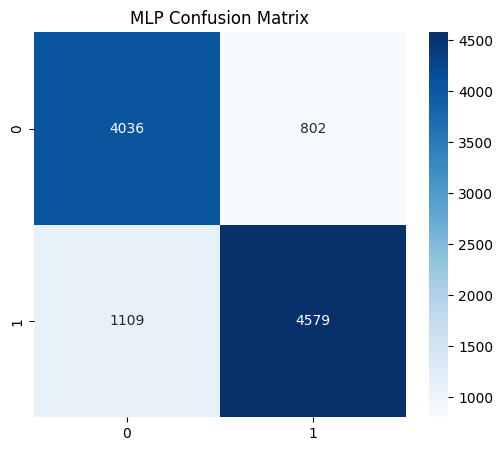

In [ ]:
cm = confusion_matrix(y_test, mlp_predictions)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('MLP Confusion Matrix')
plt.show()

In [ ]:
result = permutation_importance(
    best_mlp, x_test, y_test,
    n_repeats=10,
    random_state=42,
    scoring='recall'
)

importance_df_mlp = pd.DataFrame({
    'feature': x.columns,
    'importance': result.importances_mean,
    'std': result.importances_std
}).sort_values('importance', ascending=False)

print(importance_df_mlp.head(20))

                       feature  importance       std
70              precip_sum_96h    0.071642  0.002662
86              precip_sum_30d    0.056206  0.003673
67              precip_sum_72h    0.044884  0.001683
137                  dry_hours    0.043108  0.002379
87               precip_sum_7d    0.040418  0.002955
76             precip_sum_168h    0.026354  0.002414
73             precip_sum_120h    0.013906  0.002085
132         humidity_trend_48h    0.010601  0.001931
11                   dayofyear    0.010338  0.002803
66              precip_max_72h    0.009160  0.001110
75             precip_max_168h    0.008492  0.001364
84    precip_max_intensity_72h    0.008351  0.001020
69              precip_max_96h    0.008122  0.001147
85   precip_max_intensity_168h    0.007947  0.001282
7          solar_radiation_wm2    0.007454  0.001490
37              precip_lag_72h    0.007384  0.000786
91              rain_hours_48h    0.007068  0.001303
93             rain_hours_168h    0.006628  0.

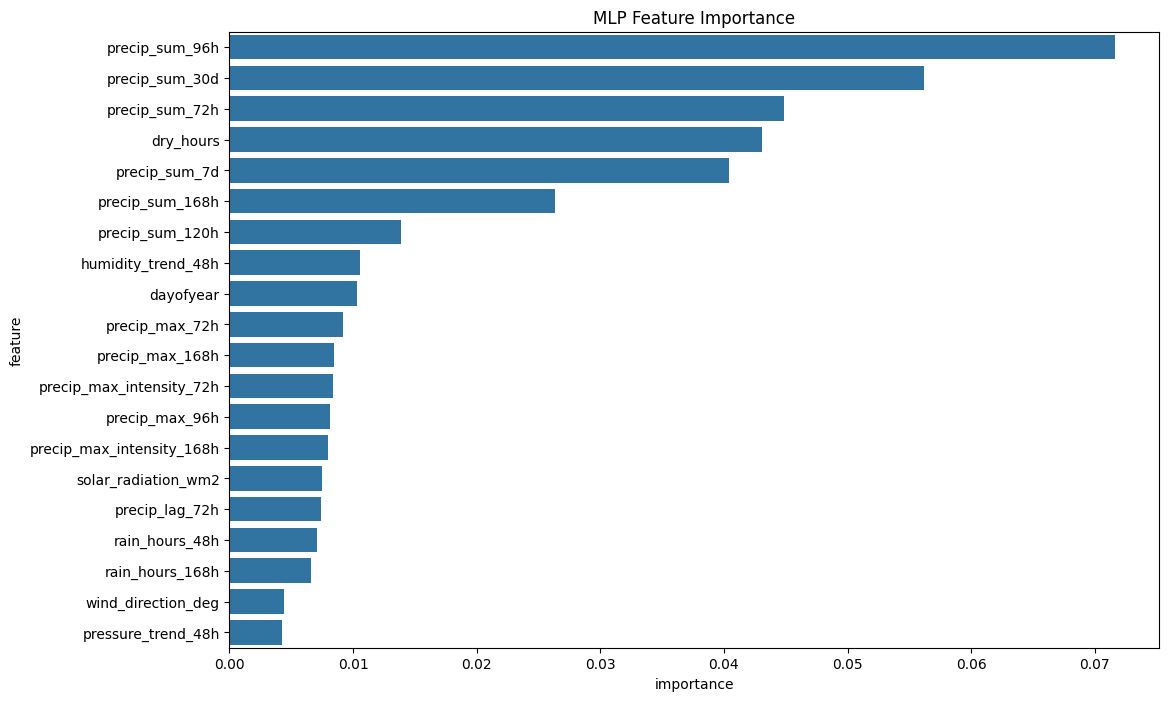

In [ ]:
plt.figure(figsize=(12,8))
sns.barplot(
    data=importance_df_mlp.head(20),
    x='importance',
    y='feature'
)
plt.title('MLP Feature Importance')
plt.show()

XGBoost

In [ ]:
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=1.5
    )

In [ ]:

params_xgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [3, 5, 7, 9]

}
#{'learning_rate': 0.03, 'max_depth': 4, 'n_estimators': 200}

In [ ]:
params_xgb = {
    'n_estimators': [200],
    'learning_rate': [0.03, 0.05],
    'max_depth': [4, 8]
}

In [ ]:
grid_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=params_xgb,
    scoring='roc_auc',
    cv=tscv,
    verbose=2,
    n_jobs=-1
    )
grid_xgb.fit(x_train, y_train)
print(grid_xgb.best_params_)

Fitting 5 folds for each of 4 candidates, totalling 20 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
4 fits failed out of a total of 20.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
4 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/xgboost/core.py", line 751, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/xgboost/sklearn.py", line 1761, in fit
    raise ValueError(
ValueError: Invalid classes inferred from unique values of `y`.  Expec

{'learning_rate': 0.03, 'max_depth': 4, 'n_estimators': 200}


In [ ]:
best_xgb = grid_xgb.best_estimator_

In [ ]:
xgb_probabilities = best_xgb.predict_proba(x_test)[:, 1]
xgb_roc_auc = roc_auc_score(y_test, xgb_probabilities)

for threshold in thresholds:
    xgb_predictions = (xgb_probabilities > threshold).astype(int)
    current_f1 = f1_score(y_test, xgb_predictions)
    if current_f1 > best_f1:
        best_f1 = current_f1
        best_threshold = threshold

xgb_predictions = (xgb_probabilities > best_threshold).astype(int)

xgb_accuracy = accuracy_score(y_test, xgb_predictions)
xgb_precision = precision_score(y_test, xgb_predictions)
xgb_recall = recall_score(y_test, xgb_predictions)
xgb_f1 = f1_score(y_test, xgb_predictions)

print(f'Best threshold: {best_threshold}')
print(f'Accuracy: {xgb_accuracy:.3f}')
print(f'Precision: {xgb_precision:.3f}')
print(f'Recall: {xgb_recall:.3f}')
print(f'F1: {xgb_f1:.3f}')
print(f'ROC_AUC: {xgb_roc_auc:.3f}')

Best threshold: 0.6
Accuracy: 0.897
Precision: 0.916
Recall: 0.892
F1: 0.904
ROC_AUC: 0.968


In [ ]:
"""
xgb_probabilities = (best_xgb.predict_proba(x_test)[:,1])
print("Threshold | Accuracy | Precision   | Recall    | F1-Score    | ROC-AUC")
print("—" * 80)
for threshold in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    xgb_predictions = (xgb_probabilities > threshold).astype(int)
    print(
        f"{threshold:.1f}       | "
        f"{accuracy_score(y_test, xgb_predictions):.3f}     | "
        f"{precision_score(y_test, xgb_predictions):.3f}      | "
        f"{recall_score(y_test, xgb_predictions):.3f}     | "
        f"{f1_score(y_test, xgb_predictions):.3f}       | "
        f"{roc_auc_score(y_test, xgb_probabilities):.3f}")

Threshold | Accuracy | Precision   | Recall    | F1-Score    | ROC-AUC
————————————————————————————————————————————————————————————————————————————————
0.3       | 0.829     | 0.767      | 0.982     | 0.861       | 0.968
0.4       | 0.865     | 0.820      | 0.961     | 0.885       | 0.968
0.5       | 0.889     | 0.872      | 0.932     | 0.901       | 0.968
0.6       | 0.897     | 0.916      | 0.892     | 0.904       | 0.968
0.7       | 0.885     | 0.961      | 0.819     | 0.885       | 0.968
0.8       | 0.842     | 0.995      | 0.711     | 0.830       | 0.968
0.9       | 0.788     | 1.000      | 0.607     | 0.756       | 0.968


In [ ]:
"""
xgb_probabilities = (best_xgb.predict_proba(x_test)[:,1])
threshold = 0.6
xgb_predictions = (xgb_probabilities > threshold).astype(int)

In [ ]:

xgb_accuracy = accuracy_score(y_test, xgb_predictions)
xgb_precision = precision_score(y_test, xgb_predictions)
xgb_recall = recall_score(y_test, xgb_predictions)
xgb_f1 = f1_score(y_test, xgb_predictions)
xgb_roc_auc = roc_auc_score(y_test, xgb_probabilities)

print(f'Accuracy: {xgb_accuracy:.2f}')
print(f'Precision: {xgb_precision:.2f}')
print(f'Recall: {xgb_recall:.3f}')
print(f'F1: {xgb_f1:.3f}')
print(f'ROC_AUC: {xgb_roc_auc:.2f}')

Accuracy: 0.90
Precision: 0.92
Recall: 0.892
F1: 0.904
ROC_AUC: 0.97


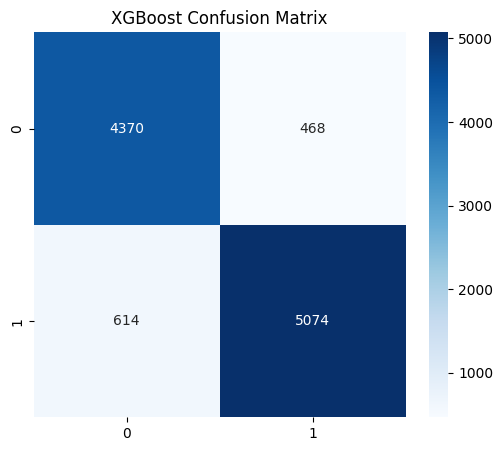

In [ ]:
cm = confusion_matrix(y_test, xgb_predictions)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('XGBoost Confusion Matrix')
plt.show()

In [ ]:
importance_df_xgb = pd.DataFrame({'feature': x.columns, 'importance': best_xgb.feature_importances_})
importance_df_xgb = (importance_df_xgb.sort_values('importance', ascending=False))
importance_df_xgb.head(20)

,feature,importance
0,precip_helman_mm,0.401821
92,rain_hours_72h,0.077066
93,rain_hours_168h,0.053122
63,precip_max_48h,0.021699
90,rain_hours_24h,0.021035
91,rain_hours_48h,0.019650
62,precip_mean_48h,0.018296
5,pressure_hpa,0.015476
56,precip_mean_24h,0.013718
1,wind_direction_deg,0.013153


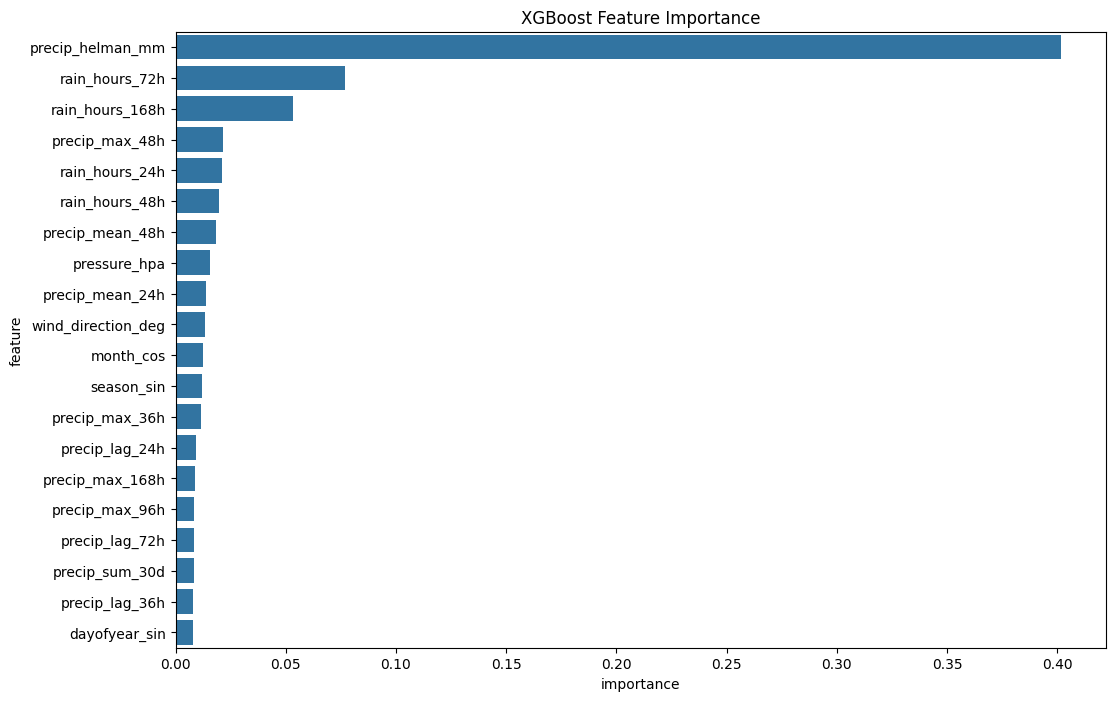

In [ ]:
plt.figure(figsize=(12,8))
sns.barplot(
    data=importance_df_xgb.head(20),
    x='importance',
    y='feature'
)
plt.title('XGBoost Feature Importance')
plt.show()

CatBoost

In [ ]:
cat_model = CatBoostClassifier(
    random_state=42,
    verbose=0,
    auto_class_weights='Balanced'
)

In [ ]:

params_cat = {
    'depth': [4, 5, 6, 7],
    'learning_rate': [0.03, 0.05],
    'iterations': [200, 300, 500]
}
#{'depth': 4, 'iterations': 300, 'learning_rate': 0.03}

In [ ]:
params_cat = {
    'depth': [5],
    'learning_rate': [0.03],
    'iterations': [300]
}

In [ ]:
grid_cat = GridSearchCV(
    estimator=cat_model,
    param_grid=params_cat,
    scoring='roc_auc',
    cv=tscv,
    verbose=2,
    n_jobs=-1
)
grid_cat.fit(x_train, y_train)
print(grid_cat.best_params_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
24 fits failed out of a total of 120.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
24 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/catboost/core.py", line 5547, in fit
    self._fit(X, y, cat_features, text_features, embedding_features, None, graph, sample_weight, None, None, None, None, baseline, use_best_model,
  File "/usr/local/lib/python3.12/dist-packages/catboost/core.py", line 2716, in _f

{'depth': 4, 'iterations': 200, 'learning_rate': 0.03}


In [ ]:
best_cat = grid_cat.best_estimator_

In [ ]:
cat_probabilities = best_cat.predict_proba(x_test)[:, 1]
cat_roc_auc = roc_auc_score(y_test, cat_probabilities)

for threshold in thresholds:
    cat_predictions = (cat_probabilities > threshold).astype(int)
    current_f1 = f1_score(y_test, cat_predictions)
    if current_f1 > best_f1:
        best_f1 = current_f1
        best_threshold = threshold

cat_predictions = (cat_probabilities > best_threshold).astype(int)

cat_accuracy = accuracy_score(y_test, cat_predictions)
cat_precision = precision_score(y_test, cat_predictions)
cat_recall = recall_score(y_test, cat_predictions)
cat_f1 = f1_score(y_test, cat_predictions)

print(f'Best threshold: {best_threshold}')
print(f'Accuracy: {cat_accuracy:.3f}')
print(f'Precision: {cat_precision:.3f}')
print(f'Recall: {cat_recall:.3f}')
print(f'F1: {cat_f1:.3f}')
print(f'ROC_AUC: {cat_roc_auc:.3f}')

Best threshold: 0.5
Accuracy: 0.864
Precision: 0.894
Recall: 0.849
F1: 0.871
ROC_AUC: 0.949


In [ ]:
"""
cat_probabilities = (best_cat.predict_proba(x_test)[:,1])
print("Threshold | Accuracy | Precision   | Recall    | F1-Score    | ROC-AUC")
print("—" * 80)
for threshold in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    cat_predictions = (cat_probabilities > threshold).astype(int)
    print(
        f"{threshold:.1f}       | "
        f"{accuracy_score(y_test, cat_predictions):.3f}     | "
        f"{precision_score(y_test, cat_predictions):.3f}      | "
        f"{recall_score(y_test, cat_predictions):.3f}     | "
        f"{f1_score(y_test, cat_predictions):.3f}       | "
        f"{roc_auc_score(y_test, cat_probabilities):.3f}")

Threshold | Accuracy | Precision   | Recall    | F1-Score    | ROC-AUC
————————————————————————————————————————————————————————————————————————————————
0.3       | 0.844     | 0.808      | 0.935     | 0.867       | 0.949
0.4       | 0.859     | 0.851      | 0.896     | 0.873       | 0.949
0.5       | 0.864     | 0.894      | 0.849     | 0.871       | 0.949
0.6       | 0.858     | 0.946      | 0.782     | 0.856       | 0.949
0.7       | 0.826     | 0.988      | 0.687     | 0.810       | 0.949
0.8       | 0.789     | 0.994      | 0.614     | 0.759       | 0.949
0.9       | 0.766     | 0.997      | 0.569     | 0.725       | 0.949


In [ ]:
"""
cat_probabilities = (best_cat.predict_proba(x_test)[:,1])
threshold = 0.5
cat_predictions = (cat_probabilities > threshold).astype(int)

In [ ]:

cat_accuracy = accuracy_score(y_test, cat_predictions)
cat_precision = precision_score(y_test, cat_predictions)
cat_recall = recall_score(y_test, cat_predictions)
cat_f1 = f1_score(y_test, cat_predictions)
cat_roc_auc = roc_auc_score(y_test, cat_probabilities)

print(f'Accuracy: {cat_accuracy:.4f}')
print(f'Precision: {cat_precision:.4f}')
print(f'Recall: {cat_recall:.4f}')
print(f'F1: {cat_f1:.4f}')
print(f'ROC_AUC: {cat_roc_auc:.4f}')

Accuracy: 0.8638
Precision: 0.8937
Recall: 0.8488
F1: 0.8707
ROC_AUC: 0.9485


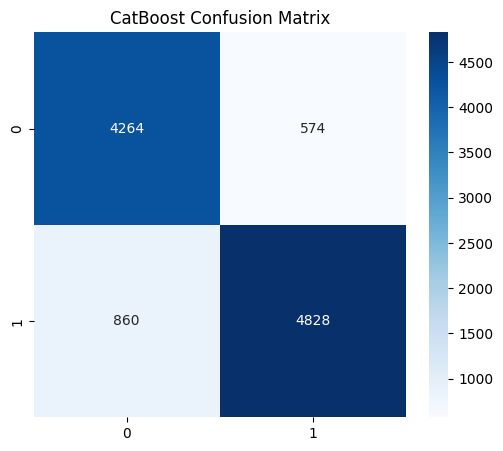

In [ ]:
cm = confusion_matrix(y_test, cat_predictions)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('CatBoost Confusion Matrix')
plt.show()

In [ ]:
importance_df_cat = pd.DataFrame({'feature': x.columns, 'importance': best_cat.feature_importances_})
importance_df_cat = (importance_df_cat.sort_values('importance', ascending=False))
importance_df_cat.head(20)

,feature,importance
93,rain_hours_168h,18.868313
5,pressure_hpa,9.744891
0,precip_helman_mm,8.423984
92,rain_hours_72h,4.374250
3,temperature_c,3.522579
36,precip_lag_48h,2.869536
39,precip_lag_120h,2.601776
19,dayofyear_cos,2.512164
6,precip_vaisala_mm,2.324305
128,pressure_trend_48h,2.196916


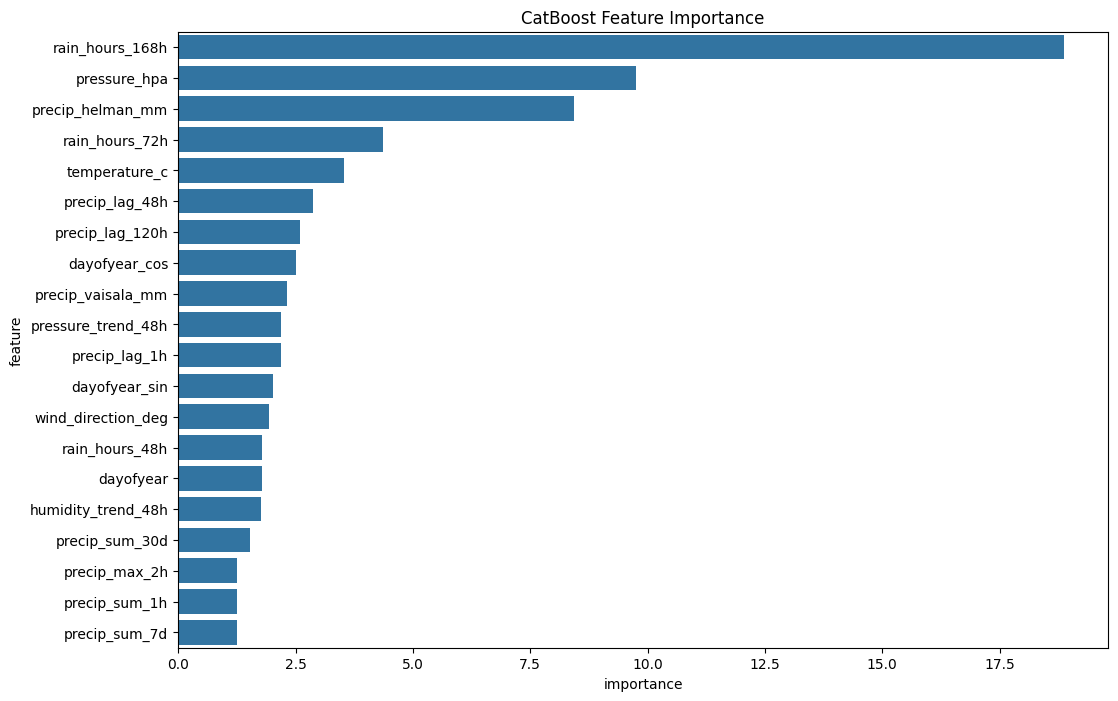

In [ ]:
plt.figure(figsize=(12,8))
sns.barplot(
    data=importance_df_cat.head(20),
    x='importance',
    y='feature'
)
plt.title('CatBoost Feature Importance')
plt.show()

Best Model

In [ ]:
comparison_df = pd.DataFrame({
    'Model': [
        'RandomForest',
        'MLP',
        'XGBoost',
        'CatBoost',
        'LightGBM'],
    'Accuracy': [
        rf_accuracy,
        mlp_accuracy,
        xgb_accuracy,
        cat_accuracy,
        lgb_accuracy],
    'Precision': [
        rf_precision,
        mlp_precision,
        xgb_precision,
        cat_precision,
        lgb_precision],
    'Recall': [
        rf_recall,
        mlp_recall,
        xgb_recall,
        cat_recall,
        lgb_recall],
    'F1': [
        rf_f1,
        mlp_f1,
        xgb_f1,
        cat_f1,
        lgb_f1],
    'ROC_AUC': [
        rf_roc_auc,
        mlp_roc_auc,
        xgb_roc_auc,
        cat_roc_auc,
        lgb_roc_auc]})

In [ ]:
comparison_df = comparison_df.sort_values(by='ROC_AUC', ascending=False)
comparison_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
2,XGBoost,0.897207,0.915554,0.892053,0.903651,0.967751
4,LightGBM,0.874976,0.906622,0.856892,0.881056,0.952571
3,CatBoost,0.863766,0.893743,0.848805,0.870694,0.948550
0,RandomForest,0.834505,0.807512,0.910865,0.856081,0.938703
1,MLP,0.818450,0.850957,0.805028,0.827356,0.907660


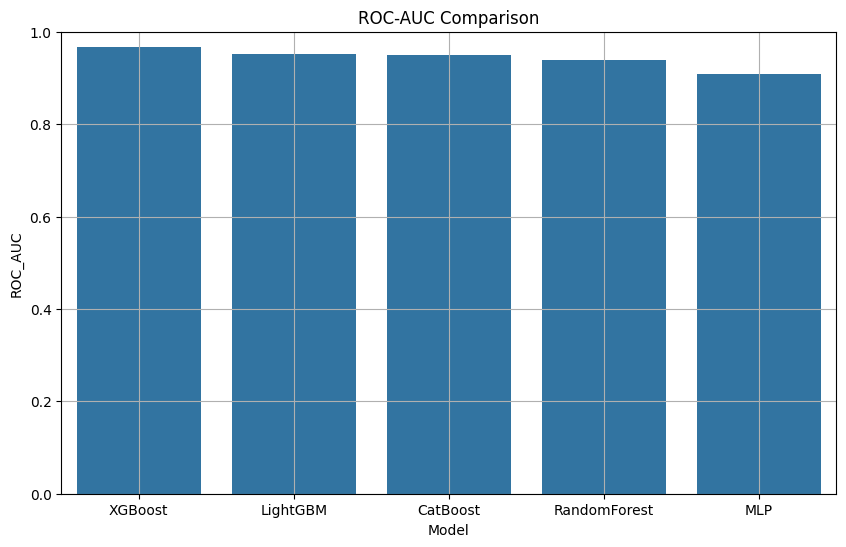

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=comparison_df,
    x='Model',
    y='ROC_AUC'
)
plt.title('ROC-AUC Comparison')
plt.ylim(0,1)
plt.grid(True)
plt.show()

In [ ]:
best_model_name = comparison_df.iloc[0]['Model']
print(f'Лучшая модель: {best_model_name}')

Лучшая модель: XGBoost


In [ ]:
if best_model_name == 'RandomForest':
    best_model = best_rf
    best_probabilities = rf_probabilities
elif best_model_name == 'MLP':
    best_model = best_xgb
    best_probabilities = xgb_probabilities
elif best_model_name == 'CatBoost':
    best_model = best_cat
    best_probabilities = cat_probabilities
elif best_model_name == 'XGBoost':
    best_model = best_xgb
    best_probabilities = xgb_probabilities
else:
    best_model = best_lgb
    best_probabilities = lgb_probabilities

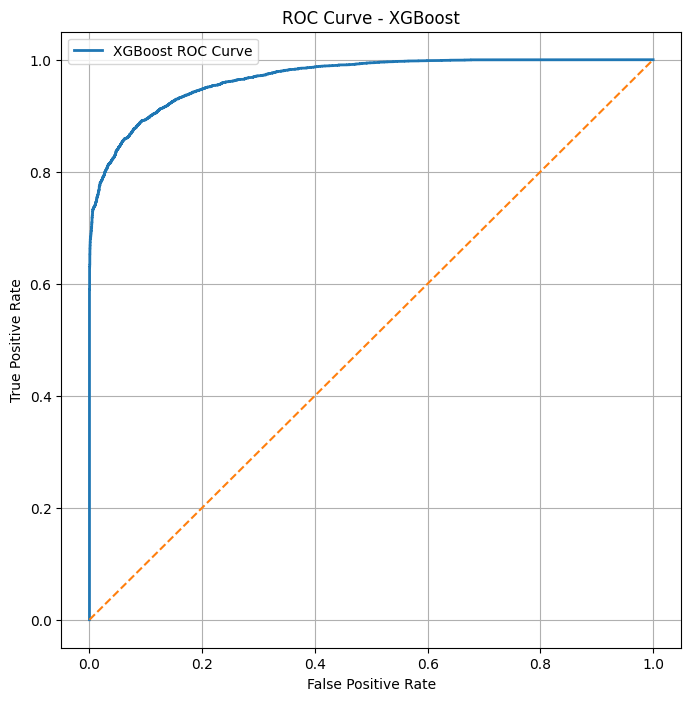

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, best_probabilities)
plt.figure(figsize=(8,8))
plt.plot(fpr, tpr, linewidth=2, label=f'{best_model_name} ROC Curve')
plt.plot([0,1],[0,1],linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve - {best_model_name}')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
joblib.dump(best_lgb, 'model_lightgbm_24h.pkl')
joblib.dump(best_rf, 'model_randomforest_24h.pkl')
joblib.dump(best_xgb, 'model_xgb_24h.pkl')
joblib.dump(best_cat, 'model_cat_24h.pkl')
joblib.dump(best_mlp, 'model_mlp_24h.pkl')

['model_mlp_24h.pkl']